<a href="https://colab.research.google.com/github/DanielSammaritani/Simple_Trading_Strategy/blob/main/Strategia_di_Trading_sulle_medie_mobili.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

The strategy is based on a possible arbitrage, infact when the "small moving average" (20 days) surpass the "long moving average" (60 DAYS), the strategy buys the assets so following the momentum.
It Does the opposite when the LMA surpass the SMA.

Download the libraries and get the data from yahoofinance

In [326]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("seaborn-v0_8")
import yfinance as yf
import pandas as pd

I chosed Leonardo as the company to investigate on, infact the defence sector got bigger year by year and it tested very good on thid strategy, in particular since 2020

In [327]:
data = yf.download("LDO.MI" ,start="2020-01-01")
print(data)

/tmp/ipykernel_2028/2546947672.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("LDO.MI" ,start="2020-01-01")
[*********************100%***********************]  1 of 1 completed

Price           Close       High        Low       Open   Volume
Ticker         LDO.MI     LDO.MI     LDO.MI     LDO.MI   LDO.MI
Date                                                           
2020-01-02   9.623543   9.770537   9.614355   9.646510  1264225
2020-01-03   9.720009   9.720009   9.559233   9.591388  1569605
2020-01-06   9.991030  10.004811   9.591388   9.720009  3268214
2020-01-07  10.124245  10.243677  10.036966  10.050747  3649794
2020-01-08  10.427421  10.427421   9.986437  10.124245  4011434
...               ...        ...        ...        ...      ...
2026-08-27  55.049999  55.680000  53.790001  54.380001  2078563
2026-08-28  52.869999  55.580002  52.869999  55.580002  2549622
2026-08-31  51.720001  53.080002  51.610001  52.959999  2263258
2026-09-01  51.049999  52.009998  50.660000  51.820000  1901563
2026-09-02  51.599998  51.900002  50.610001  51.049999   811545

[1697 rows x 5 columns]


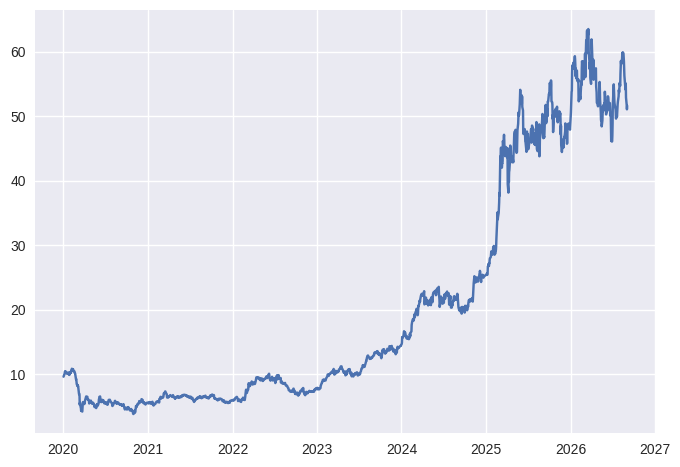

In [328]:
plt.plot(data["Close"])
plt.show()

The moving averages are 20 and 60 days

In [329]:
data["SMA"] = data["Close"].rolling(20).mean()
data["LMA"] = data["Close"].rolling(60).mean()
print(data)

Price           Close       High        Low       Open   Volume      SMA  \
Ticker         LDO.MI     LDO.MI     LDO.MI     LDO.MI   LDO.MI            
Date                                                                       
2020-01-02   9.623543   9.770537   9.614355   9.646510  1264225      NaN   
2020-01-03   9.720009   9.720009   9.559233   9.591388  1569605      NaN   
2020-01-06   9.991030  10.004811   9.591388   9.720009  3268214      NaN   
2020-01-07  10.124245  10.243677  10.036966  10.050747  3649794      NaN   
2020-01-08  10.427421  10.427421   9.986437  10.124245  4011434      NaN   
...               ...        ...        ...        ...      ...      ...   
2026-08-27  55.049999  55.680000  53.790001  54.380001  2078563  57.2985   
2026-08-28  52.869999  55.580002  52.869999  55.580002  2549622  57.1860   
2026-08-31  51.720001  53.080002  51.610001  52.959999  2263258  57.0365   
2026-09-01  51.049999  52.009998  50.660000  51.820000  1901563  56.7625   
2026-09-02  

/tmp/ipykernel_2028/1174310113.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


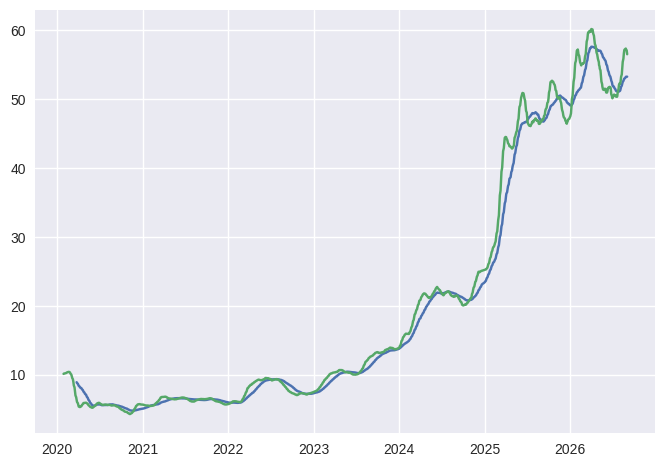

In [330]:
plt.plot(data["LMA"])
plt.plot(data["SMA"])
plt.legend()
plt.show()

We define the strategy with the where functions from numpy


In [331]:
#definiamo la strategia

data["strategia"] = np.where(data["SMA"]>data["LMA"],+1,-1)
data.dropna(inplace=True)
print(data)

Price           Close       High        Low       Open   Volume        SMA  \
Ticker         LDO.MI     LDO.MI     LDO.MI     LDO.MI   LDO.MI              
Date                                                                         
2020-03-25   5.367136   5.484731   4.836118   5.038236  9729174   6.331373   
2020-03-26   5.692361   5.738297   5.159506   5.363461  6684329   6.173354   
2020-03-27   5.549041   5.694198   5.378160   5.594977  5288644   6.026451   
2020-03-30   5.479219   5.622538   5.194417   5.549041  3493133   5.889195   
2020-03-31   5.578440   5.813631   5.374485   5.640912  6950483   5.750929   
...               ...        ...        ...        ...      ...        ...   
2026-08-27  55.049999  55.680000  53.790001  54.380001  2078563  57.298500   
2026-08-28  52.869999  55.580002  52.869999  55.580002  2549622  57.186000   
2026-08-31  51.720001  53.080002  51.610001  52.959999  2263258  57.036500   
2026-09-01  51.049999  52.009998  50.660000  51.820000  1901563 

Transoform the close price into logaritmic values, so we can add directly the % change onto the base of 100

In [332]:
data["price"] = np.log(data["Close"]/data["Close"].shift(1))
print(data)

Price           Close       High        Low       Open   Volume        SMA  \
Ticker         LDO.MI     LDO.MI     LDO.MI     LDO.MI   LDO.MI              
Date                                                                         
2020-03-25   5.367136   5.484731   4.836118   5.038236  9729174   6.331373   
2020-03-26   5.692361   5.738297   5.159506   5.363461  6684329   6.173354   
2020-03-27   5.549041   5.694198   5.378160   5.594977  5288644   6.026451   
2020-03-30   5.479219   5.622538   5.194417   5.549041  3493133   5.889195   
2020-03-31   5.578440   5.813631   5.374485   5.640912  6950483   5.750929   
...               ...        ...        ...        ...      ...        ...   
2026-08-27  55.049999  55.680000  53.790001  54.380001  2078563  57.298500   
2026-08-28  52.869999  55.580002  52.869999  55.580002  2549622  57.186000   
2026-08-31  51.720001  53.080002  51.610001  52.959999  2263258  57.036500   
2026-09-01  51.049999  52.009998  50.660000  51.820000  1901563 

In [333]:

strat = data["price"]*data["strategia"].shift(1)


In [334]:
#METRICS
#-Cumulative Returns
Cum_return_strat = np.exp(strat.sum())-1
print(Cum_return_strat)
Cum_return_bh = np.exp(data["price"].sum())-1
print(Cum_return_bh)
#-Sharpe Ratio strat
annualized_growth_strat = np.exp(strat.mean()*252)-1
annualized_risk_free_rate =np.exp(0.04244)-1
annualized_volatility = strat.std() * np.sqrt(252)
Sharpe_strat = (annualized_growth_strat-annualized_risk_free_rate)/annualized_volatility
#-Sharpe Ratio LDO
annualized_growth_LDO = np.exp((data["price"].mean())*252)-1
annualized_volatility_LDO = data["price"].std() * np.sqrt(252)
Sharpe_LDO = (annualized_growth_LDO-annualized_risk_free_rate)/annualized_volatility_LDO
print(Sharpe_strat)
print(Sharpe_LDO)
#MAX drawdown strategy
cum_log_ret = strat.cumsum()
val = np.exp(cum_log_ret)
d_max = val.cummax()
d = (d_max-val)/d_max
print(d.max())
#max drawdown bh
cum_log_ret_bh= data["price"].cumsum()
val_bh = np.exp(cum_log_ret_bh)
d_max_bh = val_bh.cummax()
d_bh = (d_max_bh - val_bh)/d_max_bh
print(d_bh.max())

2.8521436326136445
8.614066616386948
0.49973447661828413
0.9970849285257374
0.5966689508351731
0.4155260556842998
